# Customer Segmentation with K-Means Clustering & Profile Analysis
### Olist Brazilian E-Commerce Dataset

In this notebook, we:
1. Determine the optimal number of clusters ($K$) using the **Elbow Method (WCSS)** and **Silhouette Analysis**.
2. Programmatically select optimal $K$ and fit the final K-Means model.
3. Assign cluster labels to the unscaled `rfm` dataframe.
4. Generate **Cluster Profile Summary Tables**.
5. Visualize customer segments via a **3D Scatter Plot** (Matplotlib & Plotly) and a **Snake Plot** (standardized RFM profiles).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

# 1. Load Scaled and Raw RFM Datasets
rfm_path = os.path.join("..", "Data", "Processed", "rfm.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "rfm.csv")) else os.path.join("Data", "Processed", "rfm.csv")
rfm_scaled_path = os.path.join("..", "Data", "Processed", "rfm_scaled.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "rfm_scaled.csv")) else os.path.join("Data", "Processed", "rfm_scaled.csv")

rfm = pd.read_csv(rfm_path, index_col="customer_unique_id")
rfm_scaled = pd.read_csv(rfm_scaled_path, index_col="customer_unique_id")

print(f"Loaded rfm:        {rfm.shape}")
print(f"Loaded rfm_scaled: {rfm_scaled.shape}")

Loaded rfm:        (93357, 3)
Loaded rfm_scaled: (93357, 3)


## 2. Evaluate Optimal K: Elbow Method & Silhouette Scores

In [2]:
# WCSS (Elbow Method) for K=1 to 10
wcss = []
k_range_elbow = range(1, 11)
for k in k_range_elbow:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

# Silhouette Scores for K=2 to 8 (sample_size=10,000 for efficiency)
sil_scores = {}
k_range_sil = range(2, 9)
for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels, sample_size=10000, random_state=42)
    sil_scores[k] = score
    print(f"K={k} -> Silhouette Score: {score:.4f}")

K=2 -> Silhouette Score: 0.7135
K=3 -> Silhouette Score: 0.4253
K=4 -> Silhouette Score: 0.4032
K=5 -> Silhouette Score: 0.3581
K=6 -> Silhouette Score: 0.3549
K=7 -> Silhouette Score: 0.3535
K=8 -> Silhouette Score: 0.3491


## 3. Fit K-Means with Optimal K & Assign Cluster Labels

In [3]:
optimal_k = max(sil_scores, key=sil_scores.get)
print(f"Selected Optimal K: {optimal_k}")

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(rfm_scaled)

rfm["Cluster"] = cluster_labels
rfm_scaled["Cluster"] = cluster_labels

Selected Optimal K: 2


## 4. Cluster Profile Summary Table

In [4]:
summary_table = rfm.groupby("Cluster").agg(
    Customer_Count=("Recency", "count"),
    Recency_Mean=("Recency", "mean"),
    Recency_Median=("Recency", "median"),
    Frequency_Mean=("Frequency", "mean"),
    Frequency_Max=("Frequency", "max"),
    Monetary_Mean=("Monetary", "mean"),
    Monetary_Median=("Monetary", "median")
).reset_index()

summary_table["Percentage (%)"] = (summary_table["Customer_Count"] / len(rfm)) * 100

# Format and display table
formatted_summary = summary_table.style.format({
    "Customer_Count": "{:,.0f}",
    "Percentage (%)": "{:.2f}%",
    "Recency_Mean": "{:.1f} days",
    "Recency_Median": "{:.0f} days",
    "Frequency_Mean": "{:.2f}",
    "Frequency_Max": "{:.0f}",
    "Monetary_Mean": "R${:,.2f}",
    "Monetary_Median": "R${:,.2f}"
})
display(formatted_summary)

,Cluster,Customer_Count,Recency_Mean,Recency_Median,Frequency_Mean,Frequency_Max,Monetary_Mean,Monetary_Median,Percentage (%)
0,0,"90,556",238.5 days,219 days,1.00,1,R$204.34,R$109.89,97.00%
1,1,"2,801",220.3 days,199 days,2.11,15,R$454.14,R$250.96,3.00%


## 5. 3D Scatter Plot (Customer Clusters)

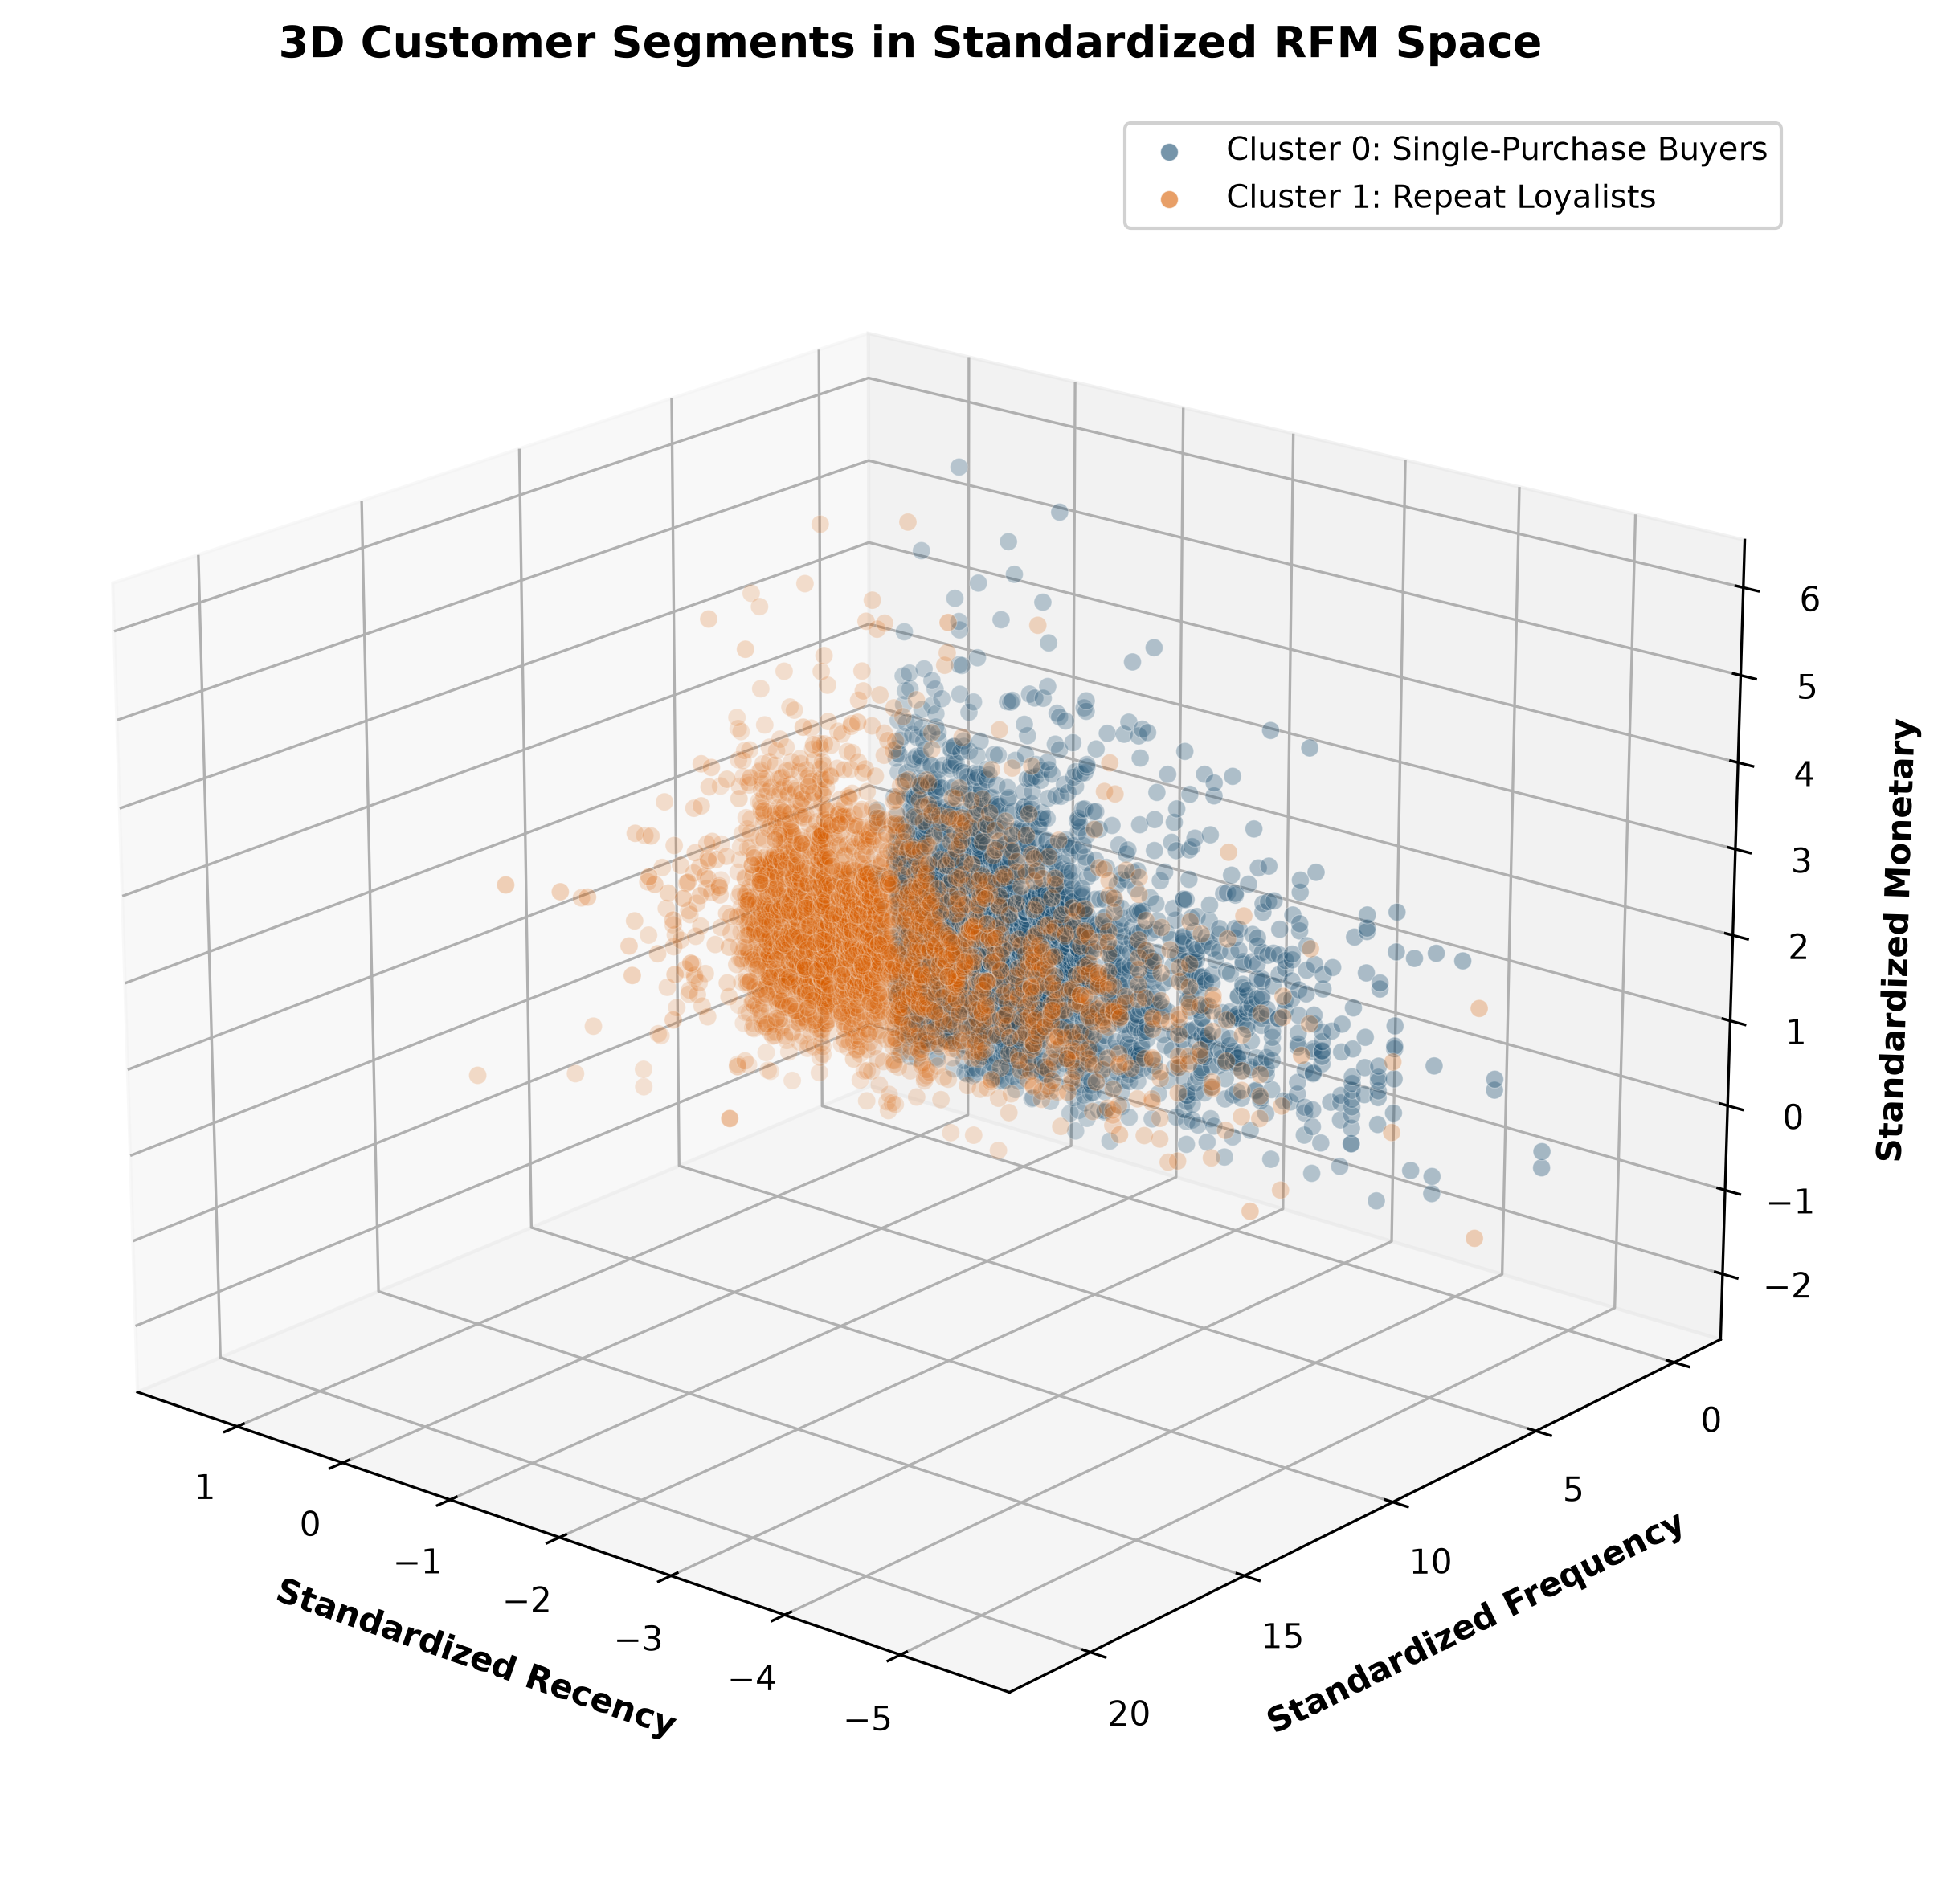

In [5]:
# Sample stratified subset for crisp 3D visualization
sample_df = rfm_scaled.groupby("Cluster", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42),
    include_groups=False
).reset_index()
sample_df["Cluster"] = rfm.loc[sample_df["customer_unique_id"], "Cluster"].values

fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection="3d")

cluster_colors = {0: "#1B4F72", 1: "#D95F02"}
cluster_names = {0: "Cluster 0: Single-Purchase Buyers", 1: "Cluster 1: Repeat Loyalists"}

for cid, grp in sample_df.groupby("Cluster"):
    ax.scatter(
        grp["Recency"],
        grp["Frequency"],
        grp["Monetary"],
        c=cluster_colors[cid],
        label=cluster_names[cid],
        alpha=0.60,
        edgecolor="white",
        linewidth=0.3,
        s=28
    )

ax.set_title("3D Customer Segments in Standardized RFM Space", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Standardized Recency", fontsize=10, fontweight="bold", labelpad=8)
ax.set_ylabel("Standardized Frequency", fontsize=10, fontweight="bold", labelpad=8)
ax.set_zlabel("Standardized Monetary", fontsize=10, fontweight="bold", labelpad=8)
ax.view_init(elev=20, azim=130)
ax.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()

## 6. Snake Plot (Segment Profiles)

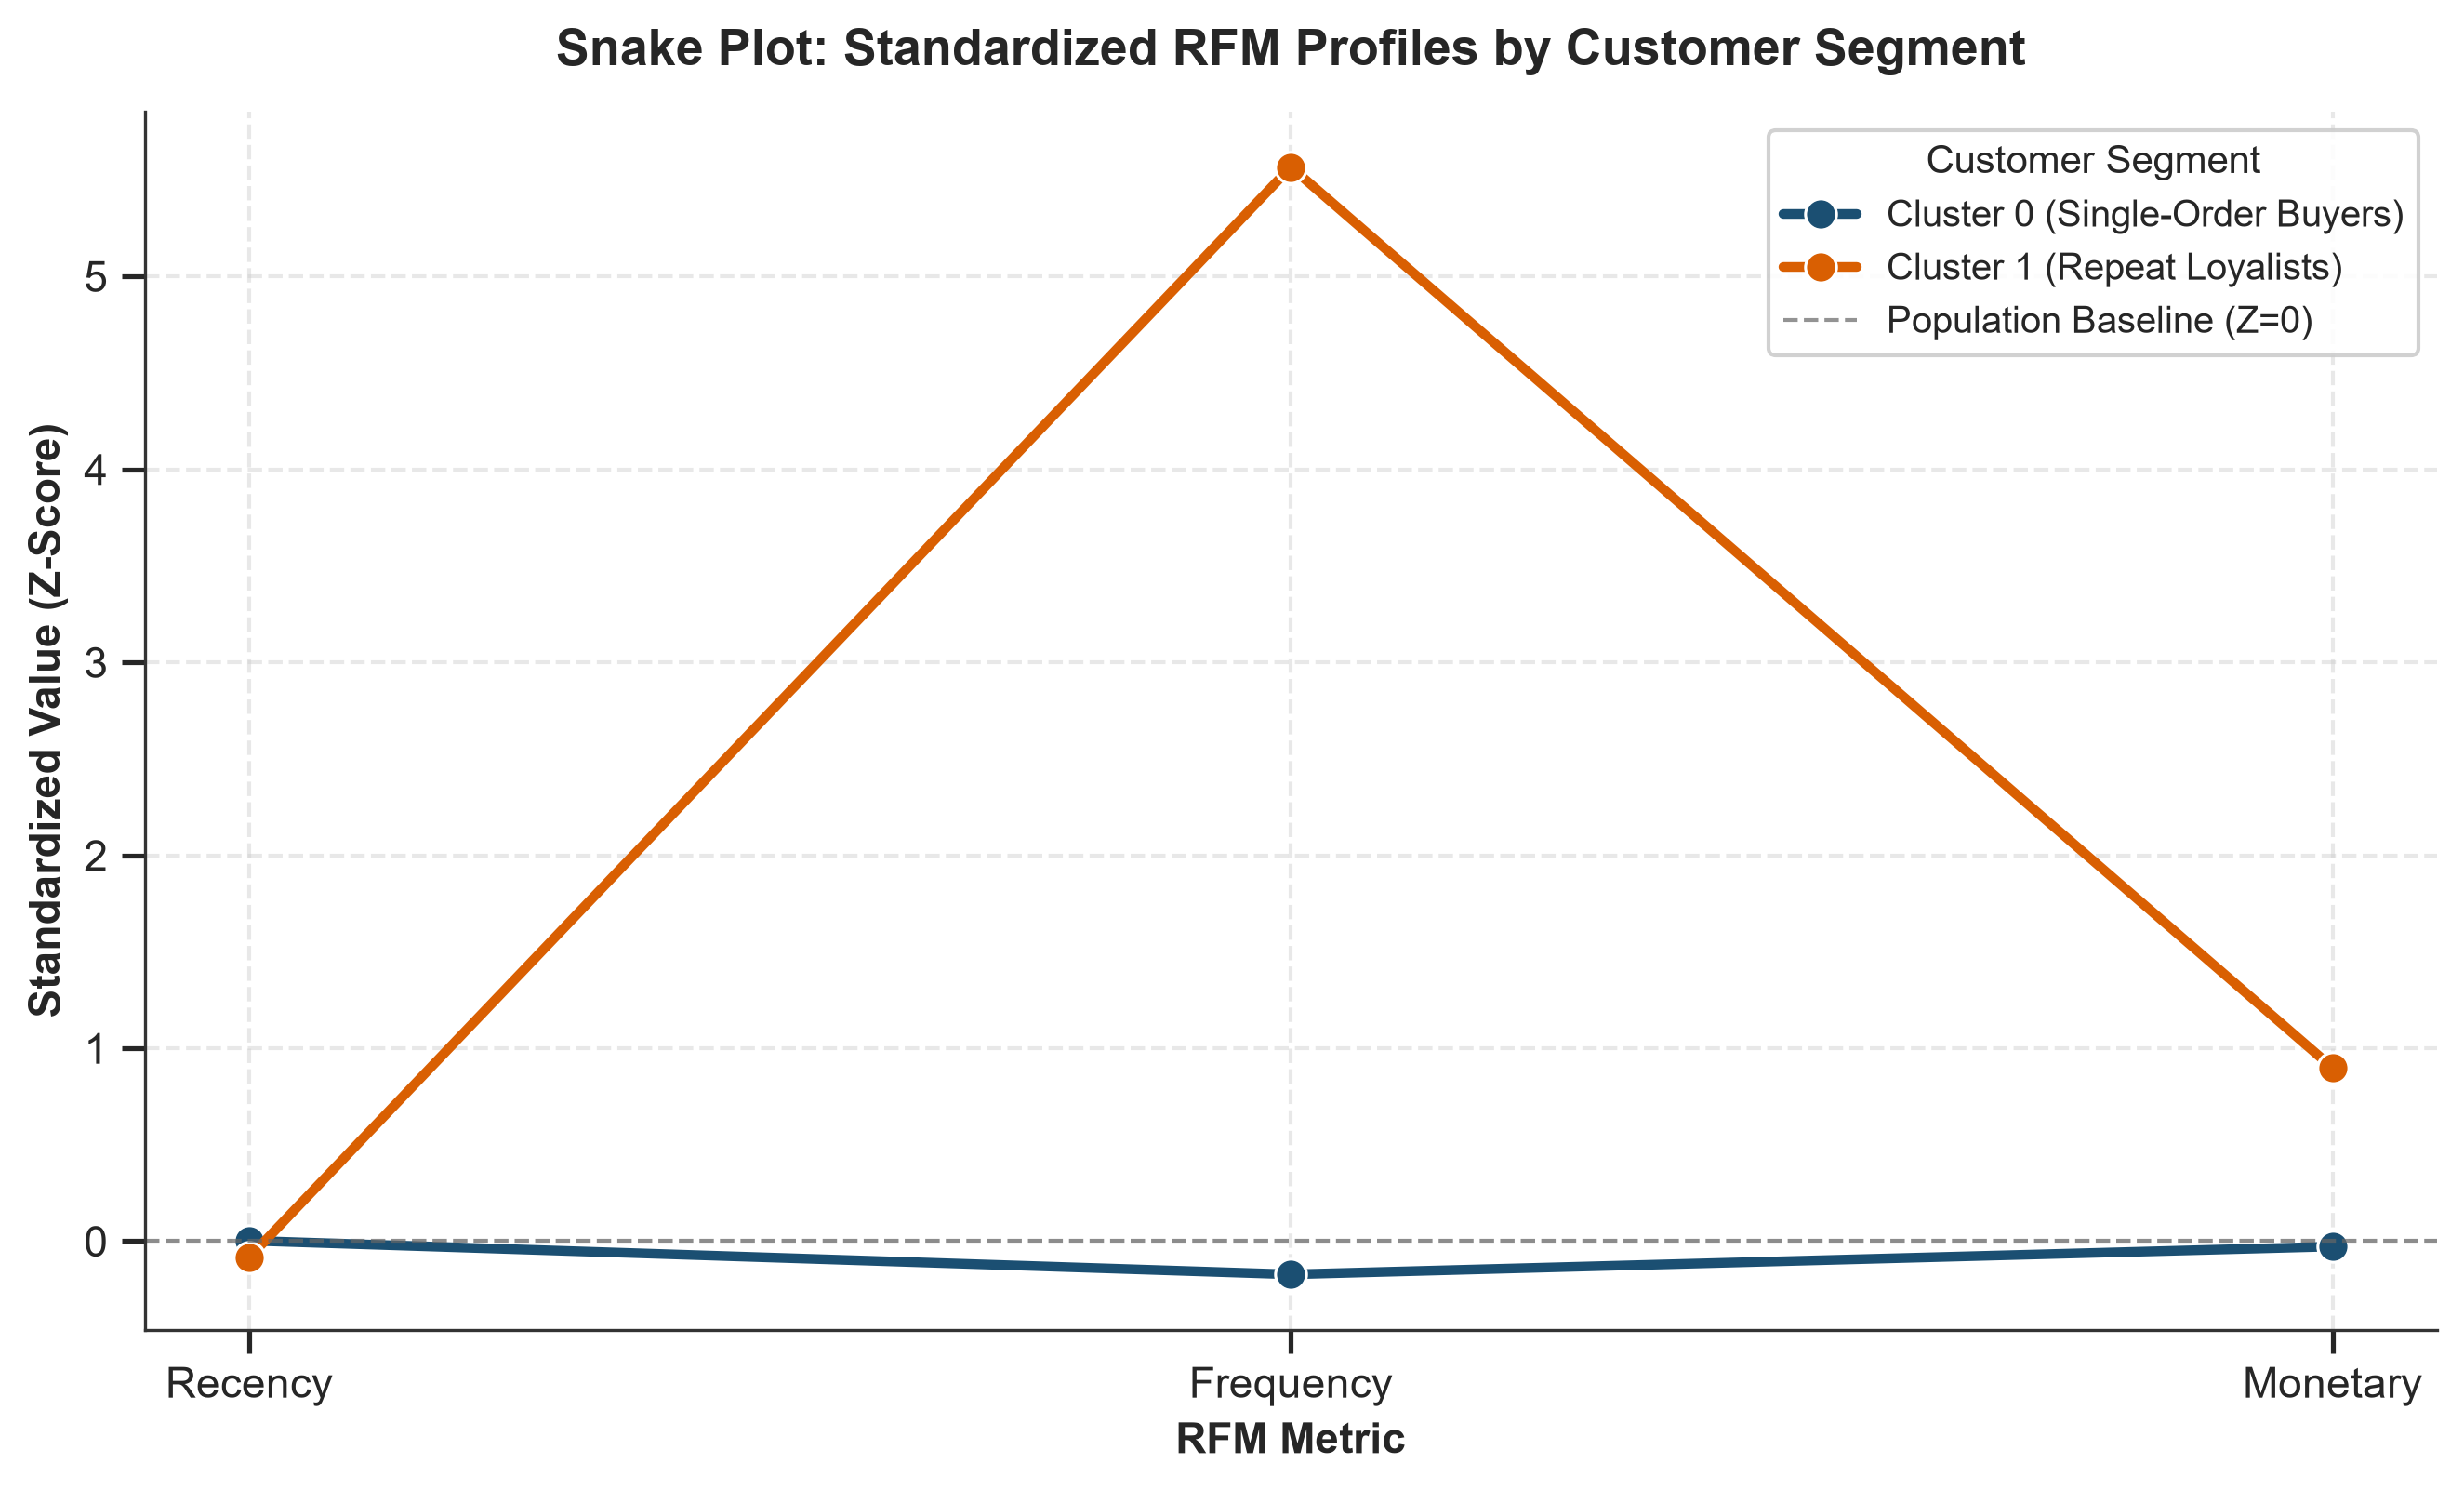

In [6]:
# Melt standardized rfm dataframe into long format
rfm_melted = pd.melt(
    rfm_scaled.reset_index(),
    id_vars=["customer_unique_id", "Cluster"],
    value_vars=["Recency", "Frequency", "Monetary"],
    var_name="Metric",
    value_name="Standardized_Value"
)
rfm_melted["Segment"] = rfm_melted["Cluster"].map({
    0: "Cluster 0 (Single-Order Buyers)",
    1: "Cluster 1 (Repeat Loyalists)"
})

plt.figure(figsize=(9, 5.5), dpi=300)
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

palette_snake = {
    "Cluster 0 (Single-Order Buyers)": "#1B4F72",
    "Cluster 1 (Repeat Loyalists)": "#D95F02"
}

sns.lineplot(
    data=rfm_melted,
    x="Metric",
    y="Standardized_Value",
    hue="Segment",
    palette=palette_snake,
    marker="o",
    markersize=8,
    linewidth=2.5,
    errorbar=None
)

plt.axhline(0, color="#666666", linestyle="--", linewidth=1, alpha=0.7, label="Population Baseline (Z=0)")
plt.title("Snake Plot: Standardized RFM Profiles by Customer Segment", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("RFM Metric", fontsize=11, fontweight="bold")
plt.ylabel("Standardized Value (Z-Score)", fontsize=11, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(title="Customer Segment", frameon=True, framealpha=0.9, fontsize=9.5, title_fontsize=10)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()